# Makemore Lesson 05

Live notes and code while following Andrej Karpathy's makemore Part 5: **Building a WaveNet**.

## Session Goals

- 接上 Part 4 的 MLP / BatchNorm 基础，观察模型结构怎么变深。
- 跟清楚 `embedding`、`flatten`、`linear`、`batchnorm`、`tanh` 之间的数据形状变化。
- 重点记录 WaveNet 思路：分层合并 context，而不是一次性 flatten 全部输入。
- 只在真正卡住的地方写短注释，保持 notebook 可跟课、可运行。

In [17]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

## Data

In [2]:
# read in all the words
words = open('../data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


## Model Skeleton

先跟课写最小结构；每加一层，都检查输入/输出 shape。

In [5]:
for x, y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


## Part 3 Copy-Paste Baseline

这段是 Karpathy 在 Part 5 开头从 Part 3 附近搬过来的 PyTorch-style 模块。这里先跑 baseline，后面再把 flat context 改成 WaveNet 风格的分层结构。

In [35]:
# Near copy paste of the layers we developed in Part 3

class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:

  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]


class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []


class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [7]:
torch.manual_seed(42);

In [39]:
# original network: flat 8-character context baseline
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 68  # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22397


In [36]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0, 11,  1, 22],
        [ 0, 14, 21,  8,  1, 13,  9, 14],
        [ 0,  0,  0,  0, 11,  1, 26,  9],
        [ 0,  0,  0,  0,  0,  8,  1, 18]])

In [37]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [20]:
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape

torch.Size([4, 5, 6, 200])

In [26]:
e = torch.randn(4, 8, 10)
torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2).shape

torch.Size([4, 4, 20])

In [38]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3022
  10000/ 200000: 2.3591
  20000/ 200000: 1.8944
  30000/ 200000: 2.0504
  40000/ 200000: 1.7724
  50000/ 200000: 1.9010
  60000/ 200000: 2.1199
  70000/ 200000: 1.8813
  80000/ 200000: 2.1102
  90000/ 200000: 2.0988
 100000/ 200000: 1.7453
 110000/ 200000: 2.0199
 120000/ 200000: 2.0172
 130000/ 200000: 1.8162
 140000/ 200000: 1.5747
 150000/ 200000: 1.5417
 160000/ 200000: 2.0207
 170000/ 200000: 1.8253
 180000/ 200000: 2.1978
 190000/ 200000: 1.9856


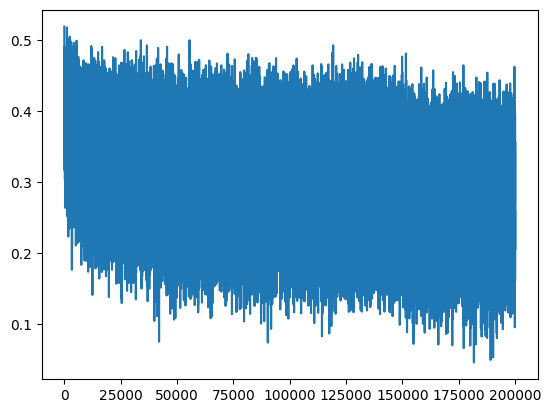

In [11]:
plt.plot(lossi)

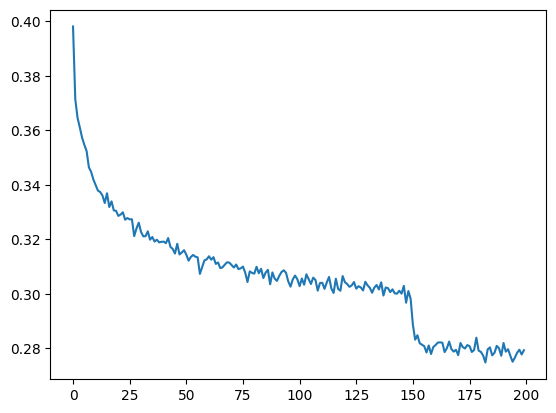

In [12]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [13]:
# put layers into eval mode, especially for BatchNorm1d
for layer in model.layers:
  layer.training = False

In [14]:
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8677643537521362
val 2.00728702545166


In [15]:
# sample from the model
for _ in range(20):

  out = []
  context = [0] * block_size
  while True:
    logits = model(torch.tensor([context]))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

aire.
zaena.
london.
ales.
joriah.
corter.
ithina.
broon.
tall.
jamaria.
brendyn.
moham.
amariah.
leelyrahe.
jenslee.
caide.
alyssaire.
yurncael.
issabesz.
rohen.


## Notes

- `block_size` 从 3 到 8：
- `flatten`：一次性 flatten vs 分层 flatten 的区别：
- `BatchNorm1d` 在 2D / 3D 输入上的行为：
- WaveNet：为什么要两两合并 context：

### Eval mode / `layer.training = False`

`eval mode` 不是新数学概念，是把 Part 3 里“评估时用 running stats”这件事，变成一个统一开关。

Part 3 前半段没有统一的 eval 开关，而是在 `split_loss` 里手动用：

```python
hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
```

Part 5 里模型被包成手写版 `Sequential`，不是 `torch.nn.Module`，所以没有 `model.eval()`。Karpathy 手动写：

```python
for layer in model.layers:
  layer.training = False
```

真正受影响的是 `BatchNorm1d`：

- `training = True`：用当前 batch 的 `mean/var`，并继续更新 `running_mean/running_var`
- `training = False`：不用当前 batch 统计量，改用训练过程中累计好的 `running_mean/running_var`

如果不切到 eval mode，会有两个问题：

1. `split_loss('val')` 不是干净评估，因为 BatchNorm 会临时用 val set / 当前 batch 的统计量适配自己。
2. sampling 时 batch size = 1，BatchNorm 用单个 context 算统计量很不稳定，生成结果会变差。

### BatchNorm1d 的 3D 输入 bug：`model.layers[3]`

`model.layers[3]` 是第一层 `BatchNorm1d`。在 hierarchical / WaveNet 版本里，它第一次收到 3D 输入：

```text
Embedding              -> (B, 8, 10)
FlattenConsecutive(2)  -> (B, 4, 20)
Linear(20, n_hidden)   -> (B, 4, n_hidden)
BatchNorm1d            -> model.layers[3]
```

这里的 `4` 不是原始第 1/2/3/4 个字母，而是 8 个字符两两合并后的 4 个字符组：

```text
[0,1] [2,3] [4,5] [6,7]
```

所以 `(B, T, C)` 里：

- `B`：batch size
- `T`：当前还剩几个 time positions / 字符组
- `C`：每个位置的 channel / feature 维度

Part 3 的旧版 BatchNorm 只处理 2D：

```python
xmean = x.mean(0, keepdim=True)
xvar = x.var(0, keepdim=True)
```

如果现在输入是 `(B, T, C)`，只对 `dim=0` 求平均会得到 `(1, T, C)`，意思是每个位置单独一套 mean/var。

但这里每个位置都用了同一个 `Linear`，应该共享同一套 channel 统计量。所以 3D 时要把 `B` 和 `T` 一起平均：

```python
if x.ndim == 2:
  dim = 0
elif x.ndim == 3:
  dim = (0, 1)

xmean = x.mean(dim, keepdim=True)
xvar = x.var(dim, keepdim=True)
```

形状对比：

```text
x.shape = (32, 4, 68)

错：x.mean(0, keepdim=True)      -> (1, 4, 68)  # 每个位置一套统计量
对：x.mean((0,1), keepdim=True)  -> (1, 1, 68)  # 所有位置共享一套统计量
```

一句话：2D 输入 `(B, C)` 时 BatchNorm 沿 `B` 统计；3D 输入 `(B, T, C)` 时 BatchNorm 要沿 `B` 和 `T` 一起统计，最后一维 `C` 才是被 normalize 的 feature/channel。

### Convolutions：为什么更 efficient，什么叫 slide over the sequence

Karpathy 最后讲 `convolution`，是在说：我们现在手写的 `FlattenConsecutive + Linear`，已经很接近 1D convolution 的思想。

当前 hierarchical / WaveNet 版本做的是分层合并：

```text
[a b c d e f g h]
        ↓ FlattenConsecutive(2)
[ab] [cd] [ef] [gh]
        ↓
[abcd] [efgh]
        ↓
[abcdefgh]
```

这个过程的核心是：先看局部相邻字符，再逐层扩大 `receptive field`。

`convolution` 可以先简单理解成：

```text
用同一套小模型 / 同一组 weights，反复处理序列里的不同局部窗口。
```

`slide over the sequence` 的意思是：一个固定大小的窗口从左到右滑过序列。比如 kernel size = 2：

```text
[a b] c d e f g h
 a [b c] d e f g h
 a b [c d] e f g h
 a b c [d e] f g h
 ...
```

每滑到一个位置，就对这个局部窗口应用同一套 weights。

和 `FlattenConsecutive(2)` 的区别：

```text
FlattenConsecutive(2):
  看不重叠窗口
  [0,1] [2,3] [4,5] [6,7]

Convolution kernel size 2:
  看滑动窗口
  [0,1] [1,2] [2,3] [3,4] [4,5] ...
```

为什么 convolution 更 efficient：

1. **Weight sharing：参数共享**

   同一套 weights 用在所有位置。不是位置 0 一套参数、位置 1 一套参数，而是同一个 pattern detector 到处用。

2. **Parallel computation：并行计算**

   所有窗口可以被整理成 tensor，一次性批量计算。PyTorch / GPU 对 convolution 有高度优化，比 Python 里手写切片、拼接、循环更快。

3. **Local structure：局部结构更自然**

   字符序列里相邻字符关系很重要。convolution 先看局部窗口，再通过多层扩大上下文，比一开始直接 flatten 全部 context 更有结构。

所以这里的直觉是：

```text
FlattenConsecutive + Linear:
  手写地把相邻字符合并，再过 Linear。

Convolution:
  用标准层自动做“滑动窗口 + 同一套 weights + 批量并行计算”。
```

一句话：`convolution` 就是把同一个局部处理器沿着 sequence 滑过去；它高效是因为 weight sharing + parallel computation。

### CUDA kernel vs convolution kernel

Karpathy 说的：

```text
not outside in Python, but inside of kernels in CUDA
```

意思是：不要在 Python 层面一个窗口一个窗口地循环算，而是把数据组织成 tensor，让 PyTorch 在底层 CUDA kernel 里并行算。

两个 `kernel` 容易混：

1. **CUDA kernel**

   GPU 上执行的一段底层并行程序。这里的 `inside of kernels in CUDA` 指的是这个。重点是工程执行方式：很多窗口一次性并行算，不由 Python loop 慢慢调度。

2. **Convolution kernel**

   卷积里的局部窗口 / filter / weights。比如 kernel size = 2，就是每次看相邻两个字符，并用同一套 weights 处理。

低效写法是 Python loop：

```python
for i in range(8):
  logits[i] = model(Xtr[[7+i]])
```

这样每次只算一个窗口，Python 负责调度很多次，开销大，也不能充分利用 GPU 并行。

高效写法是把窗口打包成一个大 tensor，然后调用一次 PyTorch operation：

```text
所有窗口 -> 一个 tensor -> 一次 PyTorch 调用 -> CUDA kernel 并行算完
```

这也是 convolutional neural network 的核心思想之一：

```text
同一个局部 detector / filter 滑过 sequence 或 image 的不同位置。
```

在 sequence 里是：

```text
[0,1]
[1,2]
[2,3]
[3,4]
...
```

在 image 里类似：一个 3x3 filter 从左到右、从上到下扫过不同 image patch。

总结：CNN 的数学直觉是“同一个局部 detector 滑过所有位置”；工程效率来自“这个滑动和计算不是 Python 循环做的，而是 PyTorch / CUDA 底层并行做的”。


## Scratch

用这里手算或临时验证 shape。

In [ ]:
# shape checks / toy experiments

## Questions

- 